In [49]:
# Carga del dataset
import pandas as pd
df = pd.read_csv("Telco_customer_churn_limpio.csv")

# Eliminar columnas irrelevantes
cols_drop = ["CustomerID","Churn_Label","City","State",
    "Zip Code","Latitude","Longitude","CLTV",
    "Gender","Phone_Service","Multiple_Lines"]

df = df.drop(columns = cols_drop, errors = "ignore")

#Visulización del dataset con las columnas eliminadas
df.head(10)

,Senior_Citizen,Partner,Dependents,Tenure_Months,Internet_Service,Online_Security,Online_Backup,Device_Protection,Tech_Support,Streaming_TV,Streaming_Movies,Contract,Paperless_Billing,Payment_Method,Monthly_Charges,Total_Charges,Churn_Value,Churn_Score
0,No,No,No,2,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,86
1,No,No,Yes,2,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,67
2,No,No,Yes,8,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1,86
3,No,Yes,Yes,28,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,84
4,No,No,Yes,49,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1,89
5,No,Yes,No,10,DSL,No,No,Yes,Yes,No,No,Month-to-month,No,Credit card (automatic),55.20,528.35,1,78
6,Yes,No,No,1,DSL,No,No,Yes,No,No,Yes,Month-to-month,Yes,Electronic check,39.65,39.65,1,100
7,No,No,No,1,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.15,20.15,1,92
8,No,Yes,Yes,47,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.35,4749.15,1,77
9,No,Yes,No,1,DSL,No,Yes,No,No,No,No,Month-to-month,No,Electronic check,30.20,30.20,1,97


In [50]:
# Selección de variable objetivo.
y = df["Churn_Value"]
X = df.drop(columns=["Churn_Value", "Churn_Score"])

X = pd.get_dummies(X, drop_first=True)

In [51]:
# Train/Test split (70/30)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (4922, 26)
X_test: (2110, 26)
y_train: (4922,)
y_test: (2110,)


In [52]:
# Entrenamiento del modelo.


In [53]:
# Entrenamiento del modelo - Logistic Regression balanceado
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


In [54]:
# Predicciones
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

,Métrica,Valor,Criterio esperado,Cumple
0,AUC,0.84,>= 0.75,Sí
1,Recall (clase 1 - churn),0.78,>= 0.70,Sí


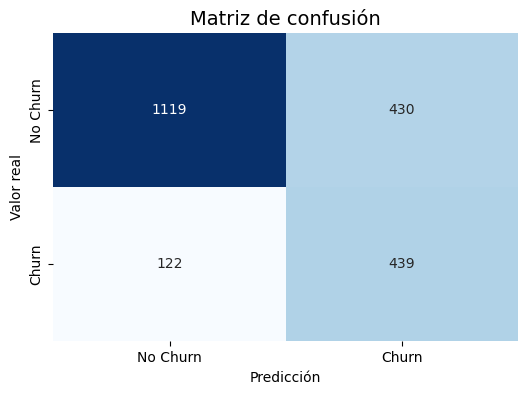

,precision,recall,f1-score,support
0,0.90,0.72,0.80,1549.00
1,0.51,0.78,0.61,561.00
accuracy,0.74,0.74,0.74,0.74
macro avg,0.70,0.75,0.71,2110.00
weighted avg,0.80,0.74,0.75,2110.00


In [55]:
# Evaluación del modelo
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, recall_score

# =========================
# Métricas principales
# =========================
auc = roc_auc_score(y_test, y_prob)
recall = recall_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

metricas_df = pd.DataFrame({
    "Métrica": ["AUC", "Recall (clase 1 - churn)"],
    "Valor": [auc, recall],
    "Criterio esperado": [">= 0.75", ">= 0.70"],
    "Cumple": ["Sí" if auc >= 0.75 else "No",
               "Sí" if recall >= 0.70 else "No"]
})

display(
    metricas_df.style
    .format({"Valor": "{:.2f}"})
    .applymap(
        lambda x: "background-color: #c6efce; color: #006100; font-weight: bold"
        if x == "Sí" else
        "background-color: #ffc7ce; color: #9c0006; font-weight: bold",
        subset=["Cumple"]
    )
    .set_caption("Reporte de métricas del modelo")
)

# =========================
# Matriz de confusión visual
# =========================
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)
plt.title("Matriz de confusión", fontsize=14)
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

# =========================
# Reporte de clasificación en tabla
# =========================
reporte_dict = classification_report(y_test, y_pred, output_dict=True)
reporte_df = pd.DataFrame(reporte_dict).transpose()

display(
    reporte_df.style
    .format("{:.2f}")
    .background_gradient(cmap="YlGnBu", subset=["precision", "recall", "f1-score"])
    .set_caption("Reporte de clasificación")
)

In [56]:
print("========== REPORTE DE EVALUACIÓN DEL MODELO ==========")
print(f"AUC: {auc:.2f}")
print(f"Recall (clase churn): {recall:.2f}")
print(f"Criterio AUC >= 0.75: {'Cumple' if auc >= 0.75 else 'No cumple'}")
print(f"Criterio Recall >= 0.70: {'Cumple' if recall >= 0.70 else 'No cumple'}")

========== REPORTE DE EVALUACIÓN DEL MODELO ==========
AUC: 0.84
Recall (clase churn): 0.78
Criterio AUC >= 0.75: Cumple
Criterio Recall >= 0.70: Cumple


In [57]:
if auc >= 0.75 and recall >= 0.70:
    print("\nConclusión: el modelo cumple con los criterios definidos para la evaluación del desempeño.")
else:
    print("\nConclusión: el modelo no cumple completamente con los criterios definidos y requiere ajustes.")


Conclusión: el modelo cumple con los criterios definidos para la evaluación del desempeño.


In [59]:
import pandas as pd

coef = model.coef_[0]
features = X_train.columns

importance = pd.DataFrame({
    "Variable": features,
    "Coeficiente": coef
})

# Variables que aumentan churn
top_positive = importance.sort_values(by="Coeficiente", ascending=False).head(10)

# Variables que reducen churn
top_negative = importance.sort_values(by="Coeficiente", ascending=True).head(10)

print("Variables que aumentan la probabilidad de churn:")
display(top_positive)

print("Variables que reducen la probabilidad de churn:")
display(top_negative)

Variables que aumentan la probabilidad de churn:


,Variable,Coeficiente
24,Payment_Method_Electronic check,0.540424
4,Partner_Yes,0.361551
22,Paperless_Billing_Yes,0.308126
6,Internet_Service_Fiber optic,0.305379
19,Streaming_Movies_Yes,0.181435
17,Streaming_TV_Yes,0.178141
25,Payment_Method_Mailed check,0.132442
3,Senior_Citizen_Yes,0.079871
23,Payment_Method_Credit card (automatic),0.076536
1,Monthly_Charges,0.005917


Variables que reducen la probabilidad de churn:


,Variable,Coeficiente
5,Dependents_Yes,-1.798654
21,Contract_Two year,-1.121776
20,Contract_One year,-0.708851
15,Tech_Support_Yes,-0.504606
9,Online_Security_Yes,-0.435271
11,Online_Backup_Yes,-0.174322
12,Device_Protection_No internet service,-0.123161
18,Streaming_Movies_No internet service,-0.123161
16,Streaming_TV_No internet service,-0.123161
7,Internet_Service_No,-0.123161


In [60]:
importance["Impacto_Absoluto"] = importance["Coeficiente"].abs()

importance_sorted = importance.sort_values(by="Impacto_Absoluto", ascending=False)

display(importance_sorted.head(15))

,Variable,Coeficiente,Impacto_Absoluto
5,Dependents_Yes,-1.798654,1.798654
21,Contract_Two year,-1.121776,1.121776
20,Contract_One year,-0.708851,0.708851
24,Payment_Method_Electronic check,0.540424,0.540424
15,Tech_Support_Yes,-0.504606,0.504606
9,Online_Security_Yes,-0.435271,0.435271
4,Partner_Yes,0.361551,0.361551
22,Paperless_Billing_Yes,0.308126,0.308126
6,Internet_Service_Fiber optic,0.305379,0.305379
19,Streaming_Movies_Yes,0.181435,0.181435


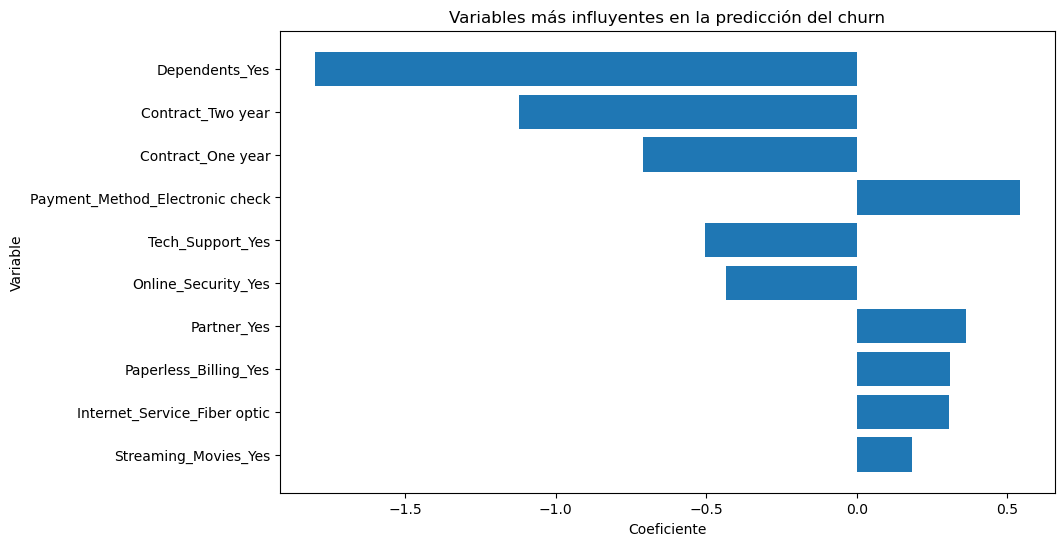

In [62]:
import matplotlib.pyplot as plt

top_vars = importance_sorted.head(10)

plt.figure(figsize=(10,6))
plt.barh(top_vars["Variable"], top_vars["Coeficiente"])
plt.xlabel("Coeficiente")
plt.ylabel("Variable")
plt.title("Variables más influyentes en la predicción del churn")
plt.gca().invert_yaxis()
plt.show()

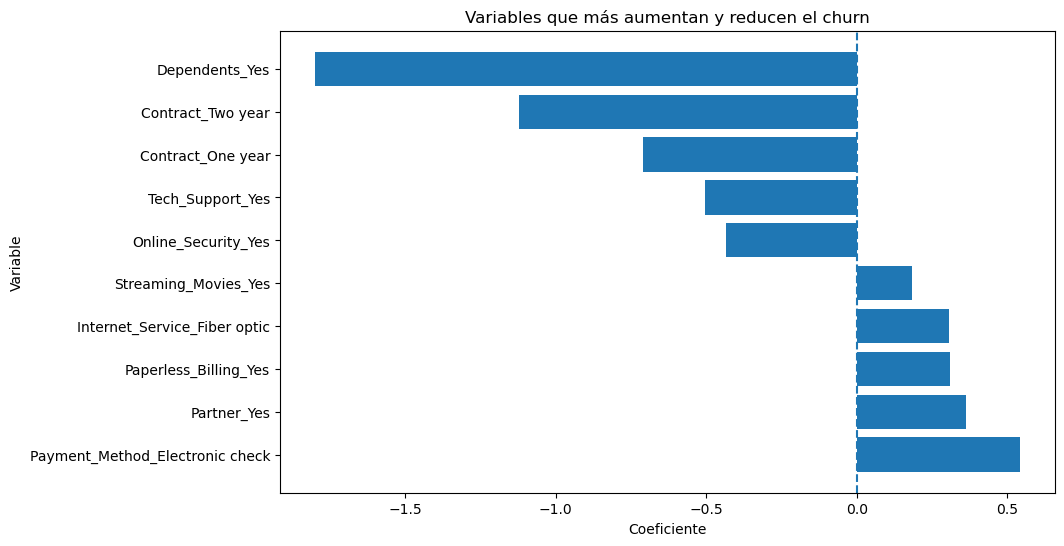

In [63]:
top_plot = importance.sort_values(by="Coeficiente", ascending=False)
top_plot = pd.concat([top_plot.head(5), top_plot.tail(5)])

plt.figure(figsize=(10,6))
plt.barh(top_plot["Variable"], top_plot["Coeficiente"])
plt.xlabel("Coeficiente")
plt.ylabel("Variable")
plt.title("Variables que más aumentan y reducen el churn")
plt.axvline(x=0, linestyle="--")
plt.show()

Top 15 variables más influyentes:


,Variable,Coeficiente,Impacto_Absoluto,Efecto,Odds_Ratio
5,Dependents_Yes,-1.798654,1.798654,Reduce churn,0.165522
21,Contract_Two year,-1.121776,1.121776,Reduce churn,0.325701
20,Contract_One year,-0.708851,0.708851,Reduce churn,0.492210
24,Payment_Method_Electronic check,0.540424,0.540424,Aumenta churn,1.716735
15,Tech_Support_Yes,-0.504606,0.504606,Reduce churn,0.603743
9,Online_Security_Yes,-0.435271,0.435271,Reduce churn,0.647089
4,Partner_Yes,0.361551,0.361551,Aumenta churn,1.435554
22,Paperless_Billing_Yes,0.308126,0.308126,Aumenta churn,1.360872
6,Internet_Service_Fiber optic,0.305379,0.305379,Aumenta churn,1.357139
19,Streaming_Movies_Yes,0.181435,0.181435,Aumenta churn,1.198937


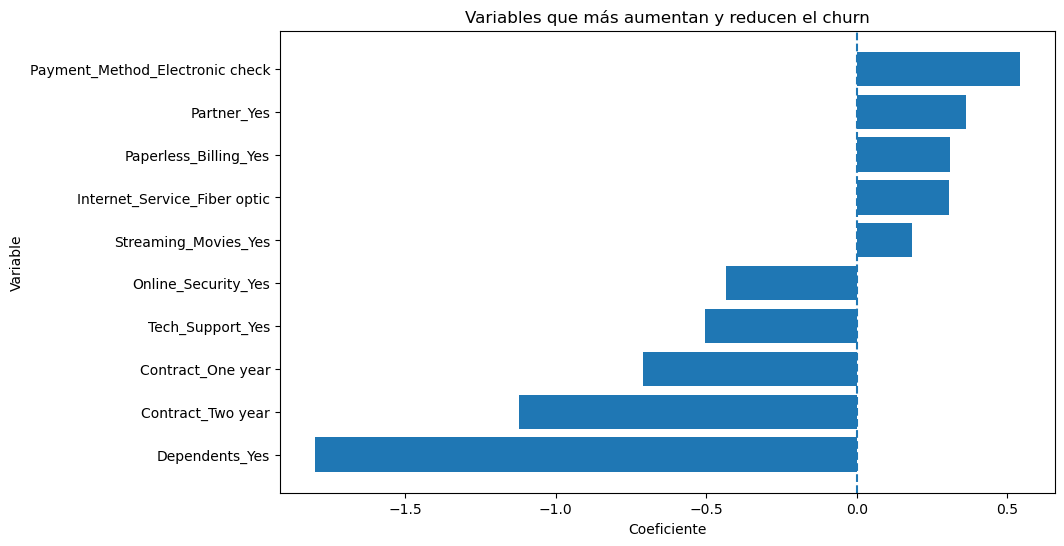

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

coef = model.coef_[0]
features = X_train.columns

importance = pd.DataFrame({
    "Variable": features,
    "Coeficiente": coef
})

importance["Impacto_Absoluto"] = importance["Coeficiente"].abs()
importance["Efecto"] = importance["Coeficiente"].apply(
    lambda x: "Aumenta churn" if x > 0 else "Reduce churn"
)
importance["Odds_Ratio"] = np.exp(importance["Coeficiente"])

importance_sorted = importance.sort_values(by="Impacto_Absoluto", ascending=False)

print("Top 15 variables más influyentes:")
display(importance_sorted.head(15))

# Gráfico
top_plot = importance.sort_values(by="Coeficiente", ascending=False)
top_plot = pd.concat([top_plot.head(5), top_plot.tail(5)])

plt.figure(figsize=(10,6))
plt.barh(top_plot["Variable"], top_plot["Coeficiente"])
plt.xlabel("Coeficiente")
plt.ylabel("Variable")
plt.title("Variables que más aumentan y reducen el churn")
plt.axvline(x=0, linestyle="--")
plt.gca().invert_yaxis()
plt.show()